In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from torch.utils.data import TensorDataset, DataLoader


device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

import os

with open("text8") as f:
    text = f.read()

words = text.split()[:200000]

chunk_size = 30
corpus = [" ".join(words[i:i+chunk_size])
          for i in range(0, len(words), chunk_size)]

# Tokenize
def tokenize(text):
    return text.lower().split()

all_sentences = [tokenize(s) for s in corpus]
all_tokens    = [w for s in all_sentences for w in s]
word_freq = Counter(all_tokens)

# Vocabulary and only keeping words appearing 3+ times
vocab     = ['<UNK>'] + sorted(w for w, c in word_freq.items() if c >= 3)
word2idx  = {w: i for i, w in enumerate(vocab)}
idx2word  = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Total tokens:    {len(all_tokens)}")

# Train / val split (80/20 by sentences)
split      = int(0.8 * len(all_sentences))
train_sents = all_sentences[:split]
val_sents   = all_sentences[split:]

Using device: mps
Vocabulary size: 7045
Total tokens:    200000


In [3]:
class NgramLM:
    def __init__(self, n=2, smoothing=0.1):
        self.n         = n
        self.smoothing = smoothing  # Laplace smoothing — handles unseen ngrams
        self.counts    = defaultdict(Counter)

    def train(self, sentences):
        for sentence in sentences:
            tokens = ['<s>'] * (self.n - 1) + sentence + ['</s>']
            for i in range(len(tokens) - self.n + 1):
                context = tuple(tokens[i:i + self.n - 1])
                word    = tokens[i + self.n - 1]
                self.counts[context][word] += 1

    def prob(self, word, context):
        """P(word | context) with Laplace smoothing."""
        context = tuple(context[-(self.n-1):])
        count   = self.counts[context][word] + self.smoothing
        total   = sum(self.counts[context].values()) + self.smoothing * VOCAB_SIZE
        return count / total

    def sentence_log_prob(self, sentence):
        tokens  = ['<s>'] * (self.n - 1) + sentence + ['</s>']
        log_p   = 0.0
        n_words = 0
        for i in range(self.n - 1, len(tokens)):
            context  = tokens[i - (self.n - 1):i]
            word     = tokens[i]
            log_p   += np.log(self.prob(word, context))
            n_words += 1
        return log_p, n_words

    '''
    This is the chain rule in action:

    log P("the cat sat") = log P("the"|<s>)
                     + log P("cat"|"the")
                     + log P("sat"|"cat")
                     + log P(</s>|"sat")     
    '''

    def perplexity(self, sentences):
        total_log_p = 0.0
        total_words = 0
        for sentence in sentences:
            log_p, n = self.sentence_log_prob(sentence)
            total_log_p += log_p
            total_words += n
        avg_log_p = total_log_p / total_words
        return np.exp(-avg_log_p)                   # Perplexity

bigram  = NgramLM(n=2, smoothing=0.1)
trigram = NgramLM(n=3, smoothing=0.1)
bigram.train(train_sents)
trigram.train(train_sents)

# Perplexity on train and val
print("\n── N-gram Perplexity ───────────────────────────────")
print(f"  Bigram  — Train: {bigram.perplexity(train_sents):.1f}"
      f"  | Val: {bigram.perplexity(val_sents):.1f}")
print(f"  Trigram — Train: {trigram.perplexity(train_sents):.1f}"
      f"  | Val: {trigram.perplexity(val_sents):.1f}")

# Sample from bigram model
def sample_bigram(model, seed='the', max_len=15):
    result = [seed]
    for _ in range(max_len):
        context   = (result[-1],)
        probs     = {w: model.prob(w, context) for w in vocab if w != '<UNK>'}
        words     = list(probs.keys())
        ps        = np.array(list(probs.values()))
        ps        = ps / ps.sum()
        next_word = np.random.choice(words, p=ps)
        if next_word == '</s>':
            break
        result.append(next_word)
    return ' '.join(result)

print("\n── Bigram Generated Text ───────────────────────────")
for _ in range(3):
    print(f"  {sample_bigram(bigram)}")


── N-gram Perplexity ───────────────────────────────
  Bigram  — Train: 336.2  | Val: 1766.2
  Trigram — Train: 498.5  | Val: 4564.5

── Bigram Generated Text ───────────────────────────
  the united ignite majority unchanged outreach elizabeth impose politically philosophy award liberation future bce di establishing
  the town fis congressional fertile unstable sentiments macrocosm neck collective prayer kazakhstan conception log rapidly nevada
  the doors stock everyday five tells ka switzerland imagery fled ethnic reactivity potentially propane refugees garden


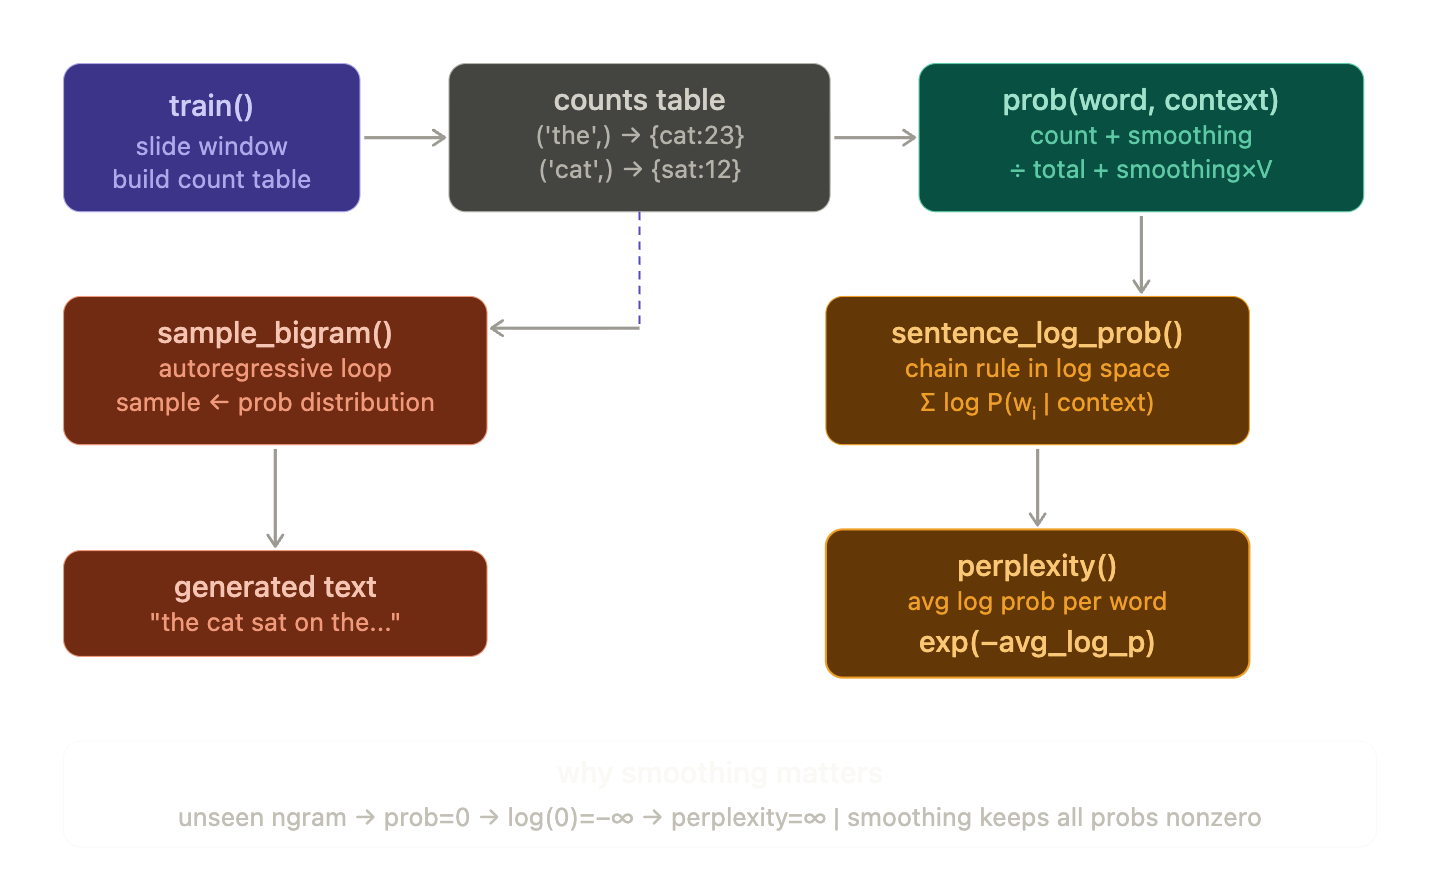

In [14]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm      = nn.LSTM(embed_size, hidden_size, num_layers,
                                 batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):

        emb     = self.dropout(self.embedding(x))        # (batch, seq_len, embed)
        out, h  = self.lstm(emb, h)                      # (batch, seq_len, hidden)
        logits  = self.fc(self.dropout(out))             # (batch, seq_len, vocab)
        return logits, h


def make_lm_sequences(sentences, word2idx, seq_len=10):
    """
    Create (input, target) pairs where target = input shifted by 1.
    This is the standard language modeling setup.
    """
    all_idxs = []
    for sentence in sentences:
        idxs = [word2idx.get(w, word2idx['<UNK>']) for w in sentence]
        all_idxs.extend(idxs)

    X, y = [], []
    for i in range(0, len(all_idxs) - seq_len, seq_len):
        X.append(all_idxs[i:i + seq_len])
        y.append(all_idxs[i + 1:i + seq_len + 1])  # shifted by 1

    return (torch.tensor(X, dtype=torch.long),
            torch.tensor(y, dtype=torch.long))

SEQ_LEN    = 20
train_X, train_y = make_lm_sequences(train_sents, word2idx, SEQ_LEN)
val_X,   val_y   = make_lm_sequences(val_sents,   word2idx, SEQ_LEN)

train_ds = TensorDataset(train_X, train_y)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

print(f"\nLSTM LM Dataset:")
#print(f"  Train: {train_ds.shape}, Val: {val_X.shape}")

# Model
lm_model  = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE, embed_size=64,
    hidden_size=256, num_layers=2
).to(device)
optimizer = torch.optim.Adam(lm_model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

EPOCHS       = 40
best_val_loss = float('inf')
patience = 3
strikes  = 0
train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    lm_model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        logits, _ = lm_model(xb.to(device))
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.to(device).reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lm_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_dl))
    
    # Validation
    lm_model.eval()
    with torch.no_grad():
        val_logits, _ = lm_model(val_X.to(device))
        val_loss      = criterion(
            val_logits.reshape(-1, VOCAB_SIZE),
            val_y.to(device).reshape(-1)
        )
    val_losses.append(val_loss.item())

    avg_train_loss = epoch_loss / len(train_dl)   
    train_ppl = np.exp(avg_train_loss)
    val_ppl = np.exp(val_loss.item())
    
    print(f"  Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.3f} (PPL: {train_ppl:.1f}) | "
        f"Val Loss: {val_loss.item():.3f} (PPL: {val_ppl:.1f})")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        torch.save(lm_model.state_dict(), 'best_lm.pth')
        strikes = 0
    else:
        strikes += 1
        if strikes >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break



LSTM LM Dataset:
  Epoch 01 | Train Loss: 7.047 (PPL: 1149.0) | Val Loss: 6.996 (PPL: 1092.3)
  Epoch 02 | Train Loss: 6.614 (PPL: 745.5) | Val Loss: 7.002 (PPL: 1099.3)
  Epoch 03 | Train Loss: 6.572 (PPL: 715.1) | Val Loss: 6.996 (PPL: 1092.2)
  Epoch 04 | Train Loss: 6.495 (PPL: 661.9) | Val Loss: 6.949 (PPL: 1041.8)
  Epoch 05 | Train Loss: 6.409 (PPL: 607.3) | Val Loss: 6.908 (PPL: 1000.2)
  Epoch 06 | Train Loss: 6.350 (PPL: 572.6) | Val Loss: 6.891 (PPL: 983.7)
  Epoch 07 | Train Loss: 6.297 (PPL: 542.8) | Val Loss: 6.842 (PPL: 936.6)
  Epoch 08 | Train Loss: 6.249 (PPL: 517.4) | Val Loss: 6.798 (PPL: 895.8)
  Epoch 09 | Train Loss: 6.207 (PPL: 496.3) | Val Loss: 6.780 (PPL: 880.0)
  Epoch 10 | Train Loss: 6.169 (PPL: 477.9) | Val Loss: 6.735 (PPL: 841.6)
  Epoch 11 | Train Loss: 6.136 (PPL: 462.0) | Val Loss: 6.737 (PPL: 843.0)
  Epoch 12 | Train Loss: 6.103 (PPL: 447.1) | Val Loss: 6.729 (PPL: 836.6)
  Epoch 13 | Train Loss: 6.075 (PPL: 434.7) | Val Loss: 6.710 (PPL: 820.6)
 

In [17]:
final_train_ppl = np.exp(train_losses[-1])
final_val_ppl   = np.exp(val_losses[-1])

print(f"\n── Final Perplexity Comparison ─────────────────────")
print(f"  Bigram LM:  Train PPL = {bigram.perplexity(train_sents):.1f}"
      f" | Val PPL = {bigram.perplexity(val_sents):.1f}")
print(f"  Trigram LM: Train PPL = {trigram.perplexity(train_sents):.1f}"
      f" | Val PPL = {trigram.perplexity(val_sents):.1f}")
print(f"  LSTM LM:    Train PPL = {final_train_ppl:.1f}"
      f" | Val PPL = {final_val_ppl:.1f}")

def generate_text(model, seed_word, max_len=15, temperature=1.0):
    """
    Temperature controls randomness:
    < 1.0 → more conservative, picks high-prob words
    > 1.0 → more creative, samples more freely
    = 1.0 → unmodified distribution
    """
    model.eval()
    result = [seed_word]
    idx    = torch.tensor(
        [[word2idx.get(seed_word, word2idx['<UNK>'])]]
    ).to(device)
    h = None

    with torch.no_grad():
        for _ in range(max_len):
            logits, h = model(idx, h)
            # Temperature scaling
            logits    = logits[:, -1, :] / temperature
            probs     = F.softmax(logits, dim=-1)
            probs[0, word2idx['<UNK>']] = 0    
            probs     = probs / probs.sum()
            next_idx  = torch.multinomial(probs, 1)
            word      = idx2word[next_idx.item()]
            result.append(word)
            idx = next_idx

    return ' '.join(result)


print("\n── LSTM Generated Text ─────────────────────────────")
for temp in [0.5, 1.0, 1.5]:
    print(f"  Temperature {temp}: {generate_text(lm_model, 'the', temperature=temp)}")


── Final Perplexity Comparison ─────────────────────
  Bigram LM:  Train PPL = 336.2 | Val PPL = 1766.2
  Trigram LM: Train PPL = 498.5 | Val PPL = 4564.5
  LSTM LM:    Train PPL = 266.3 | Val PPL = 721.0

── LSTM Generated Text ─────────────────────────────
  Temperature 0.5: the economy of the state of the north and the main system as an way of
  Temperature 1.0: the disorder was clearly by a young travel produced but use from him mary primitivism may
  Temperature 1.5: the snow niger simply belonged on nathaniel entry include de explicit termed different linear authorized a


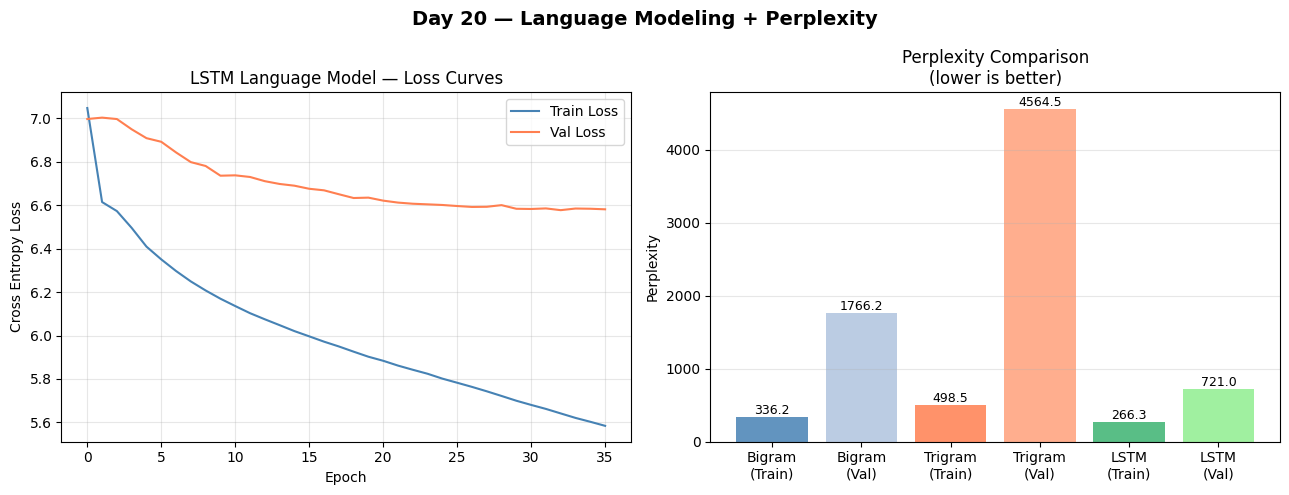

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day 20 — Language Modeling + Perplexity', fontsize=14, fontweight='bold')

# Training curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('LSTM Language Model — Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity comparison bar chart
models  = ['Bigram\n(Train)', 'Bigram\n(Val)',
           'Trigram\n(Train)', 'Trigram\n(Val)',
           'LSTM\n(Train)', 'LSTM\n(Val)']
ppls    = [bigram.perplexity(train_sents),  bigram.perplexity(val_sents),
           trigram.perplexity(train_sents), trigram.perplexity(val_sents),
           final_train_ppl,                 final_val_ppl]
colors  = ['steelblue', 'lightsteelblue',
           'coral', 'lightsalmon',
           'mediumseagreen', 'lightgreen']

bars = axes[1].bar(models, ppls, color=colors, alpha=0.85)
axes[1].set_title('Perplexity Comparison\n(lower is better)')
axes[1].set_ylabel('Perplexity')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, ppl in zip(bars, ppls):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{ppl:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()